In [22]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str((Path.cwd().parent / "src").resolve()))

from leanmetric.data.load import get_path_from_env, load_data

RAW_DATA_PATH = get_path_from_env("RAW_DATA_PATH")

Matplotlib is building the font cache; this may take a moment.


### Data loading

In [23]:
df = load_data(RAW_DATA_PATH)
df.head()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


### Data understanding

In [24]:
print(f"Shape of the dataset: {df.shape}\n")
print(f"Info of the dataset:\n{df.info()}\n")
print(f"Null values in the dataset:\n{df.isnull().sum()}\n")
print(f"Duplicated rows in the dataset: {df.duplicated().sum()}\n")

Shape of the dataset: (252, 15)

<class 'pandas.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB
Info of the dataset:
None

Null values in the dataset:
Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thi

In [25]:
print(f"Summary statistics of the dataset:")
df.describe(include="all").T

Summary statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
Density,252.0,1.055574,0.019031,0.995,1.0414,1.0549,1.0704,1.1089
BodyFat,252.0,19.150794,8.368740,0.000,12.4750,19.2000,25.3000,47.5000
Age,252.0,44.884921,12.602040,22.000,35.7500,43.0000,54.0000,81.0000
Weight,252.0,178.924405,29.389160,118.500,159.0000,176.5000,197.0000,363.1500
Height,252.0,70.148810,3.662856,29.500,68.2500,70.0000,72.2500,77.7500
Neck,252.0,37.992063,2.430913,31.100,36.4000,38.0000,39.4250,51.2000
Chest,252.0,100.824206,8.430476,79.300,94.3500,99.6500,105.3750,136.2000
Abdomen,252.0,92.555952,10.783077,69.400,84.5750,90.9500,99.3250,148.1000
Hip,252.0,99.904762,7.164058,85.000,95.5000,99.3000,103.5250,147.7000
Thigh,252.0,59.405952,5.249952,47.200,56.0000,59.0000,62.3500,87.3000


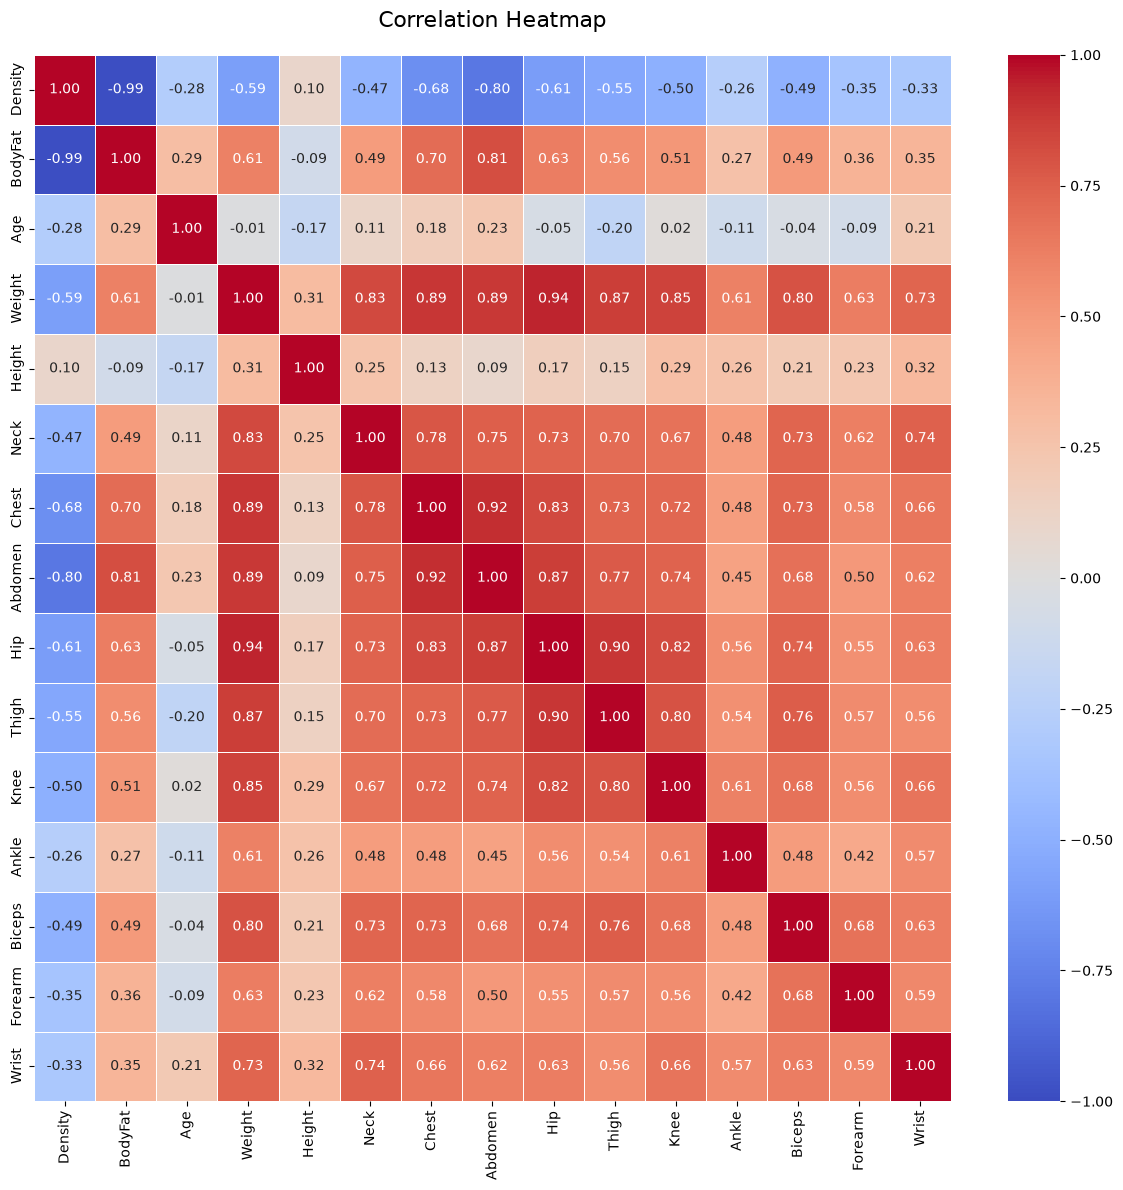

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=[np.number])
corr_df = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    corr_df,
    ax=ax,
    annot=True,
    linewidths=0.5,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)
ax.set_title("Correlation Heatmap", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

<Axes: xlabel='BodyFat', ylabel='Count'>

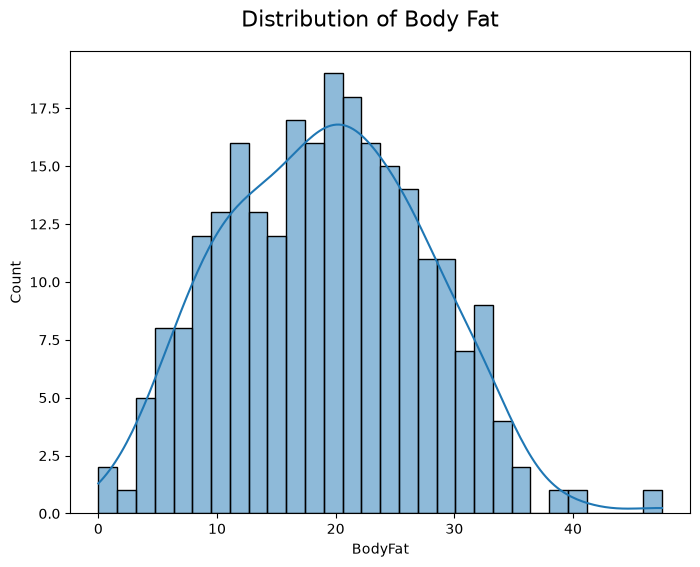

In [60]:
fig = plt.figure(figsize=(8,6))
fig.suptitle("Distribution of Body Fat", fontsize=16, y=0.95)
sns.histplot(df["BodyFat"], kde=True, bins=30)

In [63]:
corr_target = df.corr(numeric_only=True)["BodyFat"].sort_values(ascending=False)
print(f"Sorted features most correlated with Body Fat:\n{corr_target}\n")

Sorted features most correlated with Body Fat:
BodyFat    1.000000
Abdomen    0.813432
Chest      0.702620
Hip        0.625201
Weight     0.612414
Thigh      0.559608
Knee       0.508665
Biceps     0.493271
Neck       0.490592
Forearm    0.361387
Wrist      0.346575
Age        0.291458
Ankle      0.265970
Height    -0.089495
Density   -0.987782
Name: BodyFat, dtype: float64



In [79]:
q1 = df["BodyFat"].quantile(0.25)
q3 = df["BodyFat"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df["BodyFat"] < lower) | (df["BodyFat"] > upper)]

print(f"Number of outliers in BodyFat: {outliers.shape[0]}")
outliers

Number of outliers in BodyFat: 1


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
215,0.995,47.5,51,219.0,64.0,41.2,119.8,122.1,112.8,62.5,36.9,23.6,34.7,29.1,18.4
